# 머신러닝

## 지도학습

In [3]:
#선형 학습: 숫자 예측 학습 모델
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression #학습 모델 import
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #평가지표 함수

In [4]:
#Data 준비: 특성 / 타깃 => 8:2
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1) #학습 데이터는 2차원 형식으로 구종 변경
y = np.array([50, 55, 65, 70, 75]) #타깃(출력 데이터: 레벨)

In [ ]:
#학습 모델 생성(객체) => 학습
model = LinearRegression()

#모델 훈련
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[6.5]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,43.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[3.16]


In [6]:
#학습결과 -> 기울기(가중치), 절편
m = model.coef_[0] #기울기
b = model.intercept_ #절편
print(m)
print(b)

6.499999999999999
43.5


In [7]:
#학습된 모델을 이용해서 값을 예측: y, predict(x)
y_pred = model.predict(X)
print(y_pred)

[50.  56.5 63.  69.5 76. ]


In [10]:
#성능 지표
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mse)

print(f'mse: {mse}')
print(f'mae: {mae}')
print(f'r2: {r2}')
print(f'rmse: {rmse}')

mse: 1.5
mae: 1.0
r2: 0.9825581395348837
rmse: 1.224744871391589


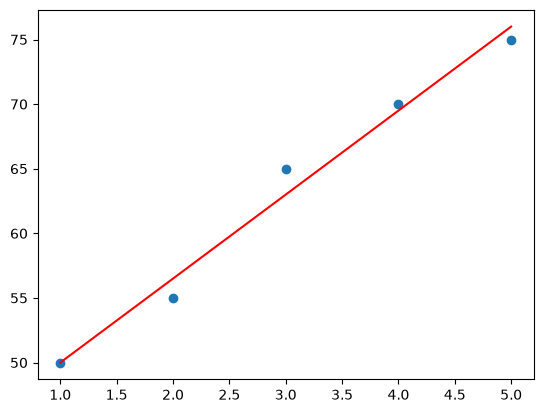

In [12]:
plt.scatter(X, y)
plt.plot(X, y_pred, color='red')

In [13]:
#예측: 6, 8, 10
new_hour = np.array([6, 8, 10]).reshape(-1, 1)
predict_score = model.predict(new_hour)
print(predict_score)

[ 82.5  95.5 108.5]


=== 데이터 첫 5행 ===
        Size         Price
0  24.981605  36495.505246
1  48.028572  54927.264367
2  39.279758  48663.076351
3  33.946339  37891.681719
4  16.240746  28145.618112

Size와 Price 간의 상관계수 : 0.9632


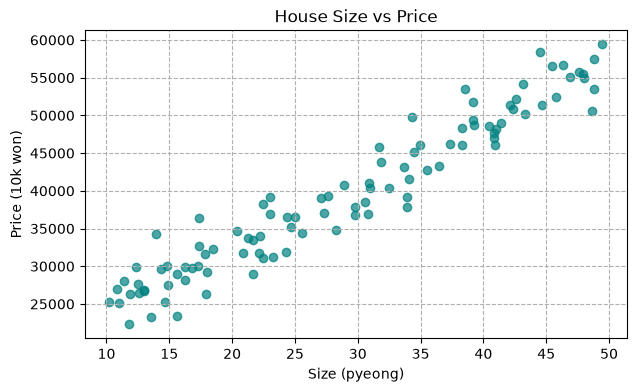

In [14]:
#가상 주택 평수 대비 가격
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 재현성을 위한 난수 시드 설정
np.random.seed(42)

# 2. 데이터 생성 : 평수 (Size) 10~50평, 총 100세대
size = np.random.uniform(10, 50, 100)

# 주택 가격 (Price): 기본 15000 + 평당 850 + 노이즈
price = 15000 + 850 * size + np.random.normal(0, 3000, 100)

df_house = pd.DataFrame({'Size': size, 'Price': price})
print("=== 데이터 첫 5행 ===")
print(df_house.head())

# 3. EDA: 산점도와 변수 간 상관계수 구하기
correlation = df_house['Size'].corr(df_house['Price'])
print(f"\nSize와 Price 간의 상관계수 : {correlation:.4f}")

#4. 결과 시각화
plt.figure(figsize=(7, 4))
plt.scatter(df_house['Size'], df_house['Price'], color='teal', alpha=0.7)
plt.title('House Size vs Price')
plt.xlabel('Size (pyeong)')
plt.ylabel('Price (10k won)')
plt.grid(True, linestyle='--')
plt.show()

In [19]:
#선형 학습: 숫자 예측 학습 모델
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression #학습 모델 import
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score #평가지표 함수
from sklearn.model_selection import train_test_split #훈련, 실험 => 8:2

# 1. 특성 (X)과 타겟 (y) 설정 (Scikit-learn 입력 규격 : X는 2차원 DataFrame, y는 1차원 Series)
X = df_house[['Size']]
y = df_house['Price']

#2. 훈련 데이터와 테스트 데이터의 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#3. 
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(80, 1) (80,)
(20, 1) (20,)


In [20]:
model = LinearRegression()

#훈련
model.fit(X_train, y_train)

#결과 확인: 기울기와 절편
print(model.coef_[0])
print(model.intercept_)

819.8985486220415
15729.754472155288


In [21]:
#테스트 데이터를 이용해서 예측값
y_pred = model.predict(X_test) #y_test

#평가 지표
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

#평가 지표
print(f'mse: {mse}')
print(f'mae: {mae}')
print(f'rmse: {rmse}')
print(f'r2: {r2}')

mse: 5883295.623453009
mae: 1774.027733756932
rmse: 2425.5505815078377
r2: 0.9446078584352587
